# HPO Synthetic Recovery (New Model)

This notebook runs the updated hierarchical HPO model with:
- 5 assessors
- 20 lists per assessor
- epsilon (error) fixed at 0.01
- beta sweep across specified values

It generates synthetic data, runs MCMC, computes metrics, and saves PO_plot visualizations.


In [1]:
# ───────────────────────────────────────────────────────────────
#  Bootstrap: add project root AND ensure src/ is a package
# ───────────────────────────────────────────────────────────────
import os
import sys
import pkgutil
from pathlib import Path

current_dir = Path.cwd()
project_root = current_dir.parents[0]
src_dir = project_root / "src"
utils_dir = src_dir / "utils"

for d in (src_dir, utils_dir):
    d.mkdir(parents=True, exist_ok=True)
    init_file = d / "__init__.py"
    if not init_file.exists():
        init_file.touch()

project_root_str = str(project_root)
if project_root_str not in sys.path:
    sys.path.insert(0, project_root_str)

print("Project root:", project_root_str)
print("src package found?", pkgutil.find_loader("src") is not None)

import json
import math
import random
from typing import Dict, List

import numpy as np
import matplotlib
if "ipykernel" in sys.modules:
    try:
        import matplotlib_inline
        matplotlib.use("module://matplotlib_inline.backend_inline")
    except Exception:
        pass
else:
    matplotlib.use("Agg")
import matplotlib.pyplot as plt

from src.utils.po_fun import BasicUtils, GenerationUtils, build_hierarchical_partial_orders_optimized
from src.utils.po_accelerator_nle_optimized import HPO_LogLikelihoodCache_Optimized
from src.mcmc.hpo_po_hm_mcmc_k_optim import mcmc_simulation_hpo_k_optim
from src.utils.hpo_model_evaluation import (
    structural_hamming_distance,
    precision_recall,
    f1_score,
    edge_accuracy,
    identifiability_metrics,
    compute_waic_from_results,
)

try:
    import pandas as pd
    HAVE_PANDAS = True
except Exception:
    HAVE_PANDAS = False

try:
    from src.utils.po_fun_plot import PO_plot
    PO_PLOT_AVAILABLE = True
    PO_PLOT_IMPORT_ERROR = None
except Exception as exc:
    PO_PLOT_AVAILABLE = False
    PO_PLOT_IMPORT_ERROR = exc
    print(f"PO_plot unavailable: {exc}")


Project root: /Users/dongqing/Desktop/hpo_inference_agent
src package found? True


## Configuration
Adjust these values to change the simulation.

In [2]:
config = {
    "num_items": 8,
    "num_assessors": 5,
    "K": 2,
    "rho_true": 0.3,
    "tau_true": 0.7,
    "min_choice_set_size": 2,
    "max_choice_set_size": 6,
    "trace_count": 20,
    "betas": [0.8, 1.5],
    "epsilon": 0.01,
    "random_seed": 42,
    "output_dir": Path("notebooks/outputs/hpo_synthetic_recovery_notebook"),
    "mcmc": {
        "num_iterations": 50000,
        "burn_in_fraction": 0.5,
        "dr": 0.95,
        "drrt": 0.95,
        "softmax_lambda": 1.0,
        "softmax_beta_prior": (2.0, 1.0),
        "softmax_beta_stepsize": 0.1,
        "cycle_length": 500,
    },
    "analysis": {
        "edge_prob_threshold": 0.5,
        "identifiability_entropy_threshold": 0.6,
    },
}

config["output_dir"].mkdir(parents=True, exist_ok=True)
print("Output dir:", config["output_dir"])


Output dir: notebooks/outputs/hpo_synthetic_recovery_notebook


## Generate hierarchical latent structure (U0, Ua, true HPO)

In [3]:
rng = np.random.default_rng(config["random_seed"])
random.seed(config["random_seed"])
np.random.seed(config["random_seed"])

items = list(range(config["num_items"]))
assessors = list(range(1, config["num_assessors"] + 1))

M_a_list = GenerationUtils.generate_subsets(len(assessors), config["num_items"])
M_a_dict = {a: sorted(subset) for a, subset in zip(assessors, M_a_list)}

U_global = GenerationUtils.generate_U(config["num_items"], config["K"], config["rho_true"])
Sigma = BasicUtils.build_Sigma_rho(config["K"], config["rho_true"])

U_a_dict = {}
for idx_a, assessor in enumerate(assessors):
    Ma = M_a_list[idx_a]
    Ua = np.zeros((len(Ma), config["K"]), dtype=float)
    cov_mat = (1.0 - config["tau_true"] ** 2) * Sigma
    for i_loc, j_global in enumerate(Ma):
        mean_vec = config["tau_true"] * U_global[j_global, :]
        Ua[i_loc, :] = rng.multivariate_normal(mean=mean_vec, cov=cov_mat)
    U_a_dict[assessor] = Ua

h_U_true = build_hierarchical_partial_orders_optimized(
    M0=items,
    assessors=assessors,
    M_a_dict=M_a_dict,
    U0=U_global,
    U_a_dict=U_a_dict,
)

print("Assessors:", assessors)
print("True HPO keys:", sorted(h_U_true.keys()))


Assessors: [1, 2, 3, 4, 5]
True HPO keys: [0, 1, 2, 3, 4, 5]


The global partial order matrix is:
[[0 0 0 1 0 0 0 0]
 [0 0 0 1 0 0 0 0]
 [1 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0]
 [1 1 0 0 0 0 0 0]
 [0 0 1 0 0 0 0 0]
 [0 0 0 0 0 0 0 0]
 [0 0 0 0 1 1 1 0]]


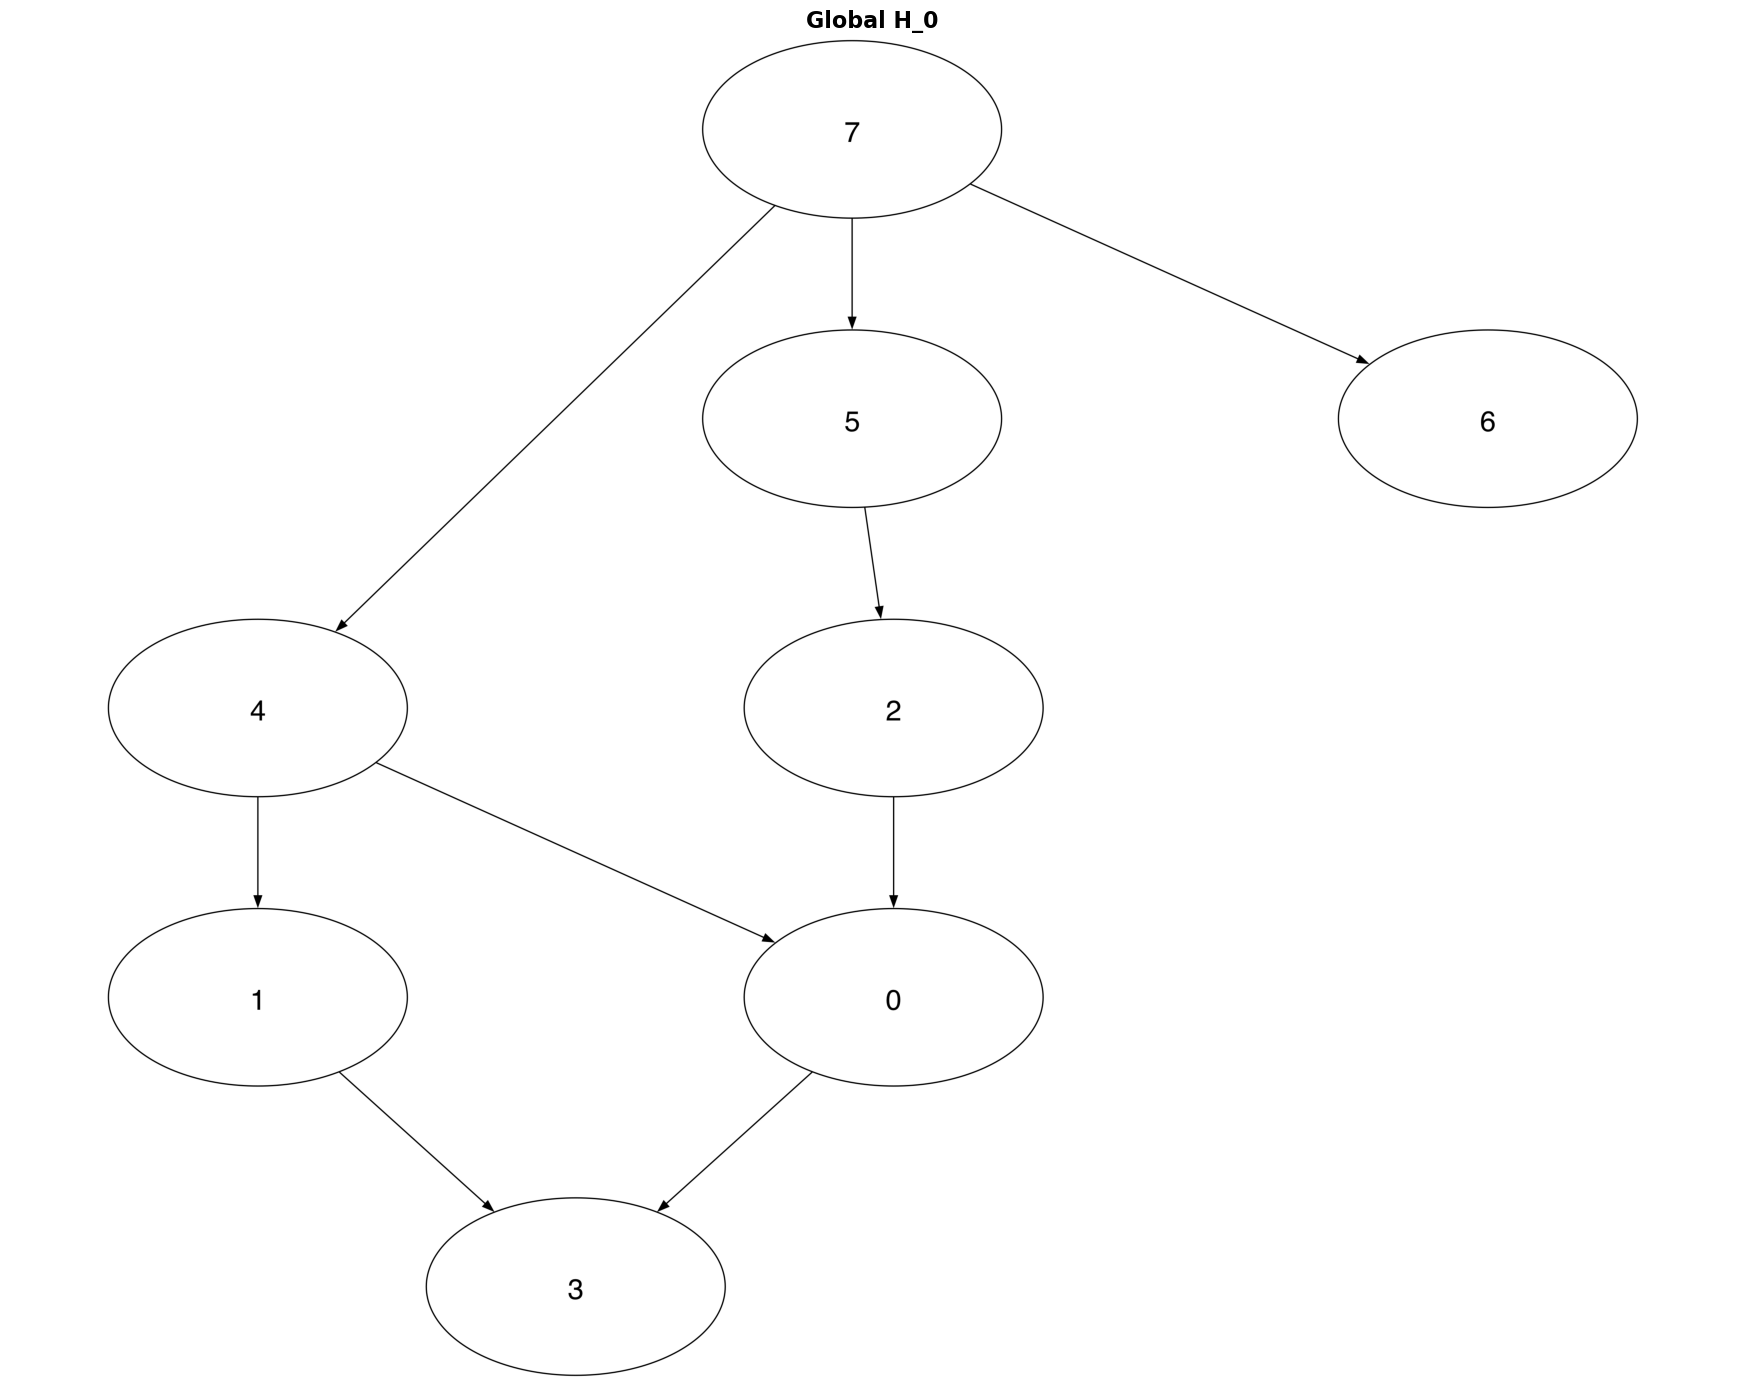

Assessor 1 has partial order matrix:
[0, 1, 2, 4, 5, 6, 7]
[[0 0 0 0 0 1 0]
 [0 0 0 0 0 0 0]
 [0 0 0 1 1 0 0]
 [1 1 0 0 0 0 0]
 [1 0 0 0 0 0 0]
 [0 0 0 0 0 0 0]
 [0 0 0 1 0 0 0]]


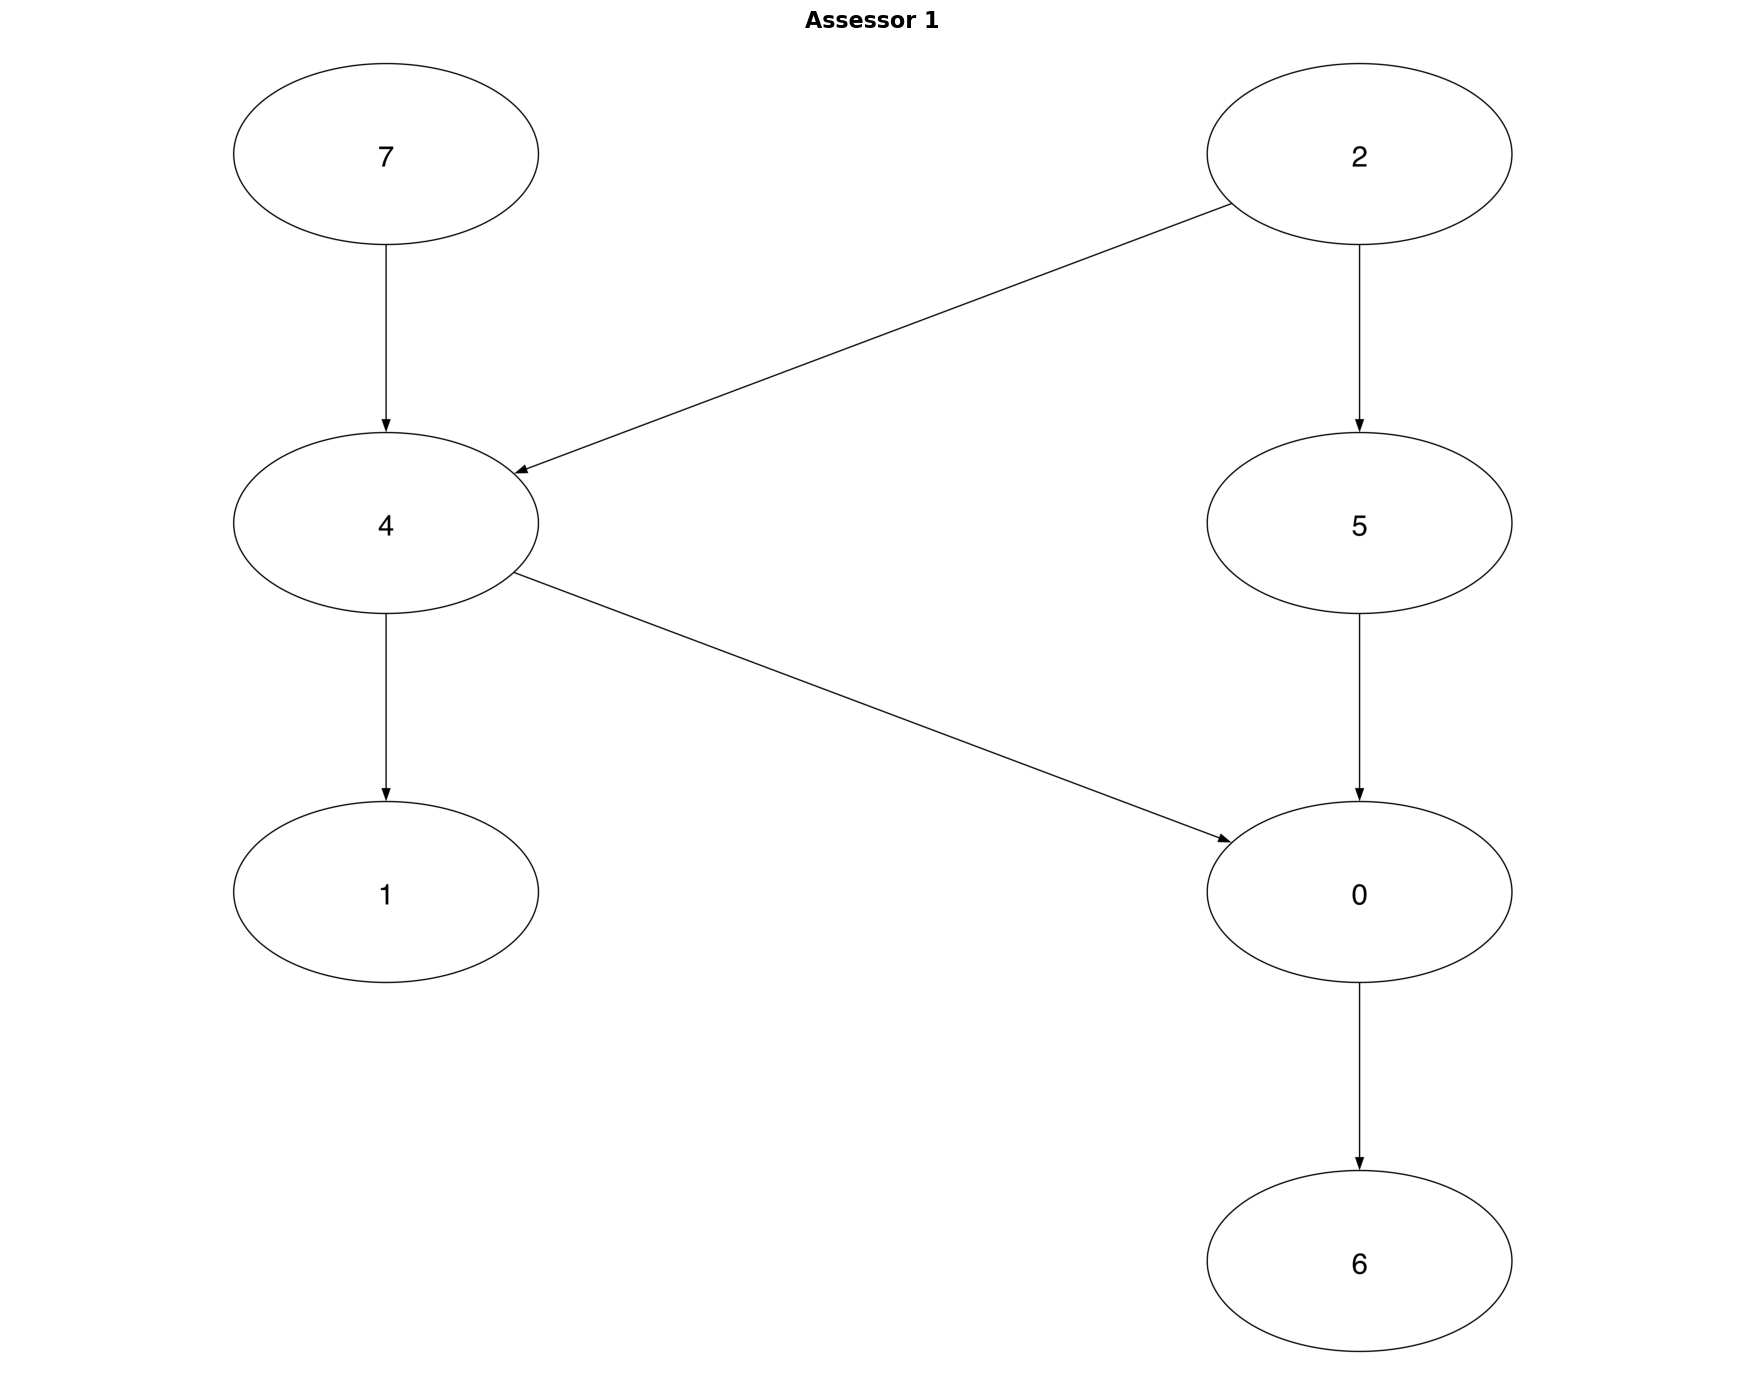

Assessor 2 has partial order matrix:
[0, 1, 2, 4, 5, 6, 7]
[[0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0]
 [1 1 1 0 1 0 0]
 [0 0 0 0 0 0 0]
 [1 0 0 0 0 0 0]
 [0 0 0 1 0 0 0]]


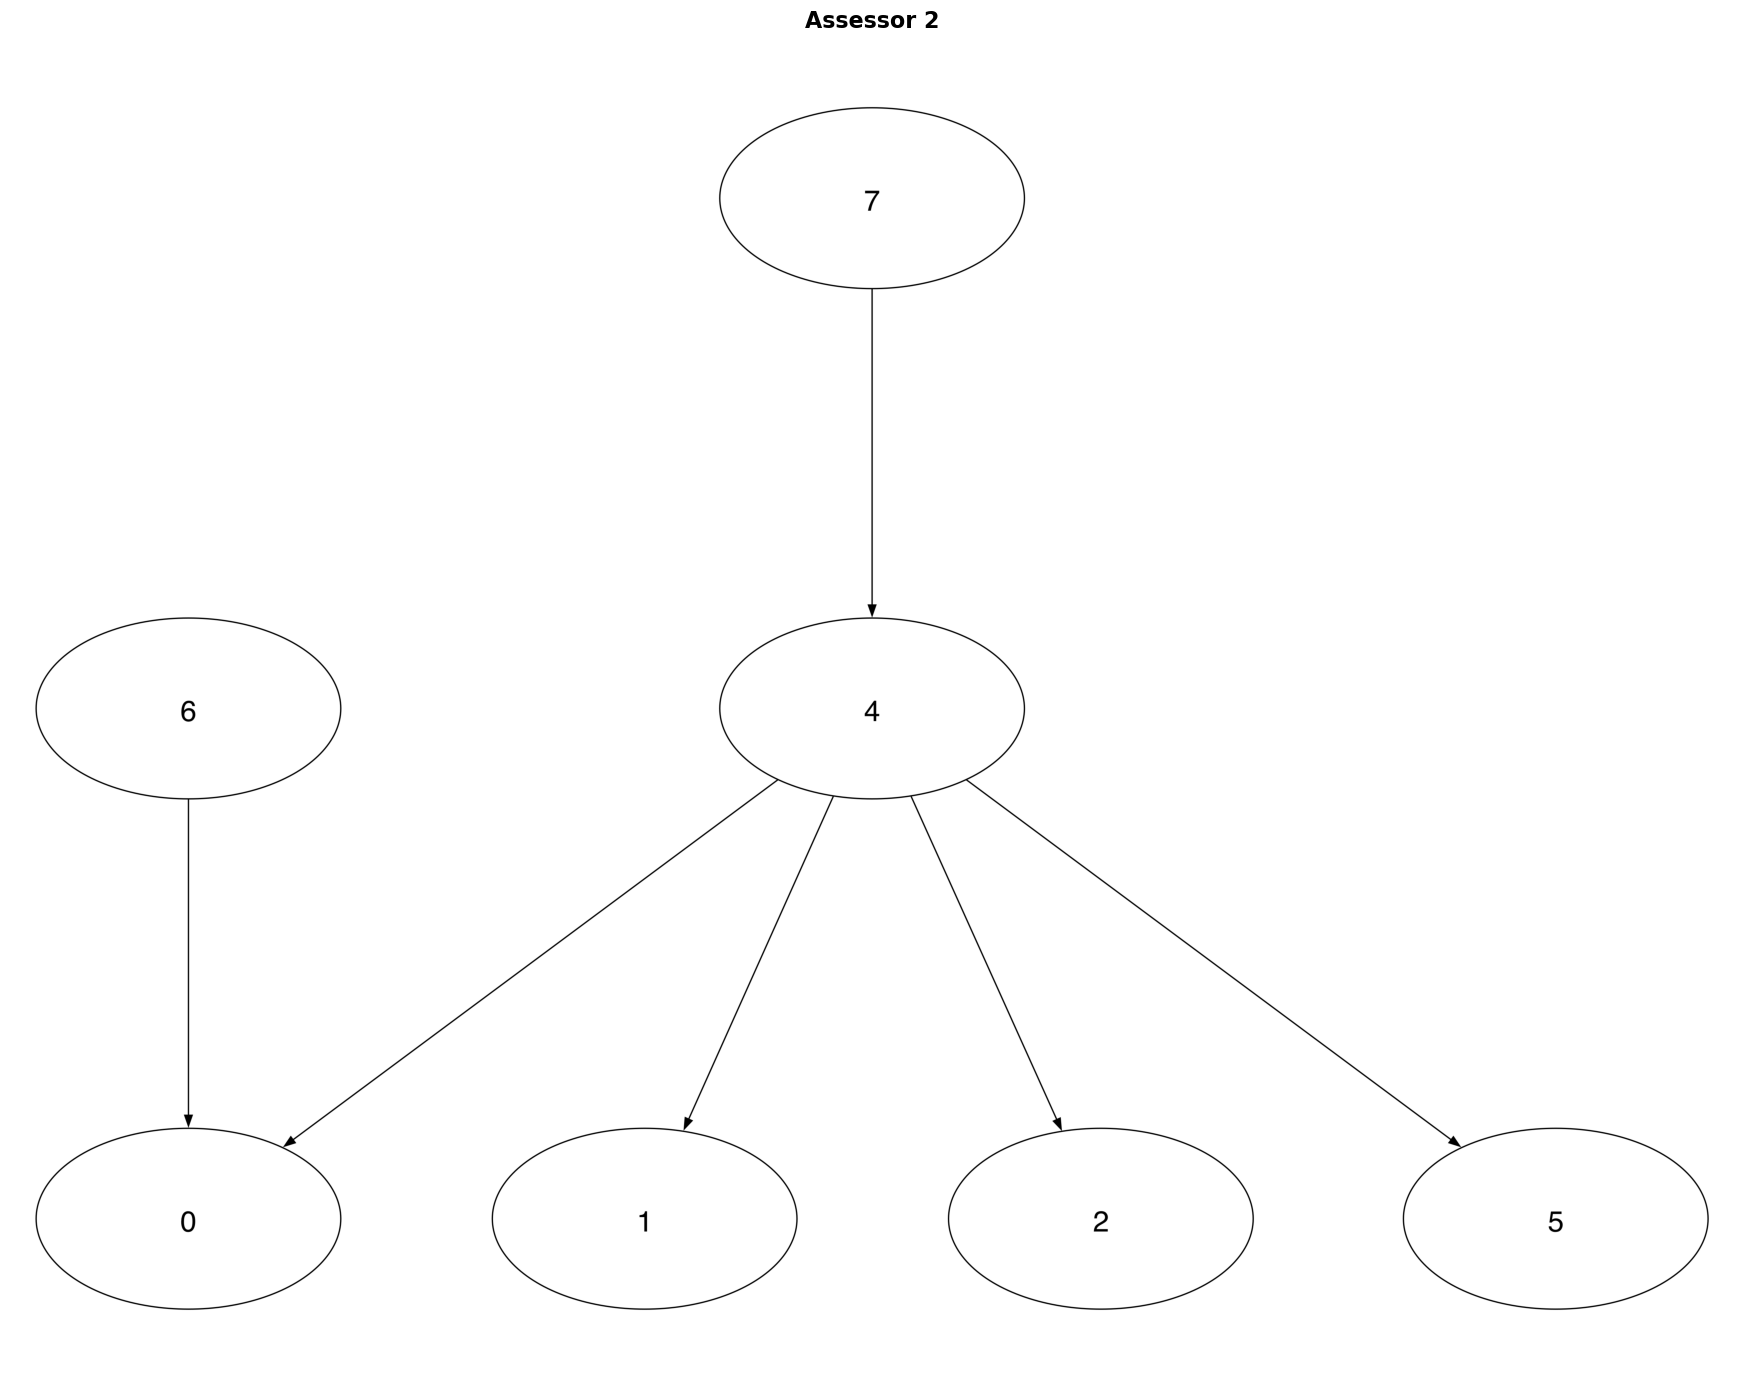

Assessor 3 has partial order matrix:
[0, 7]
[[0 0]
 [0 0]]


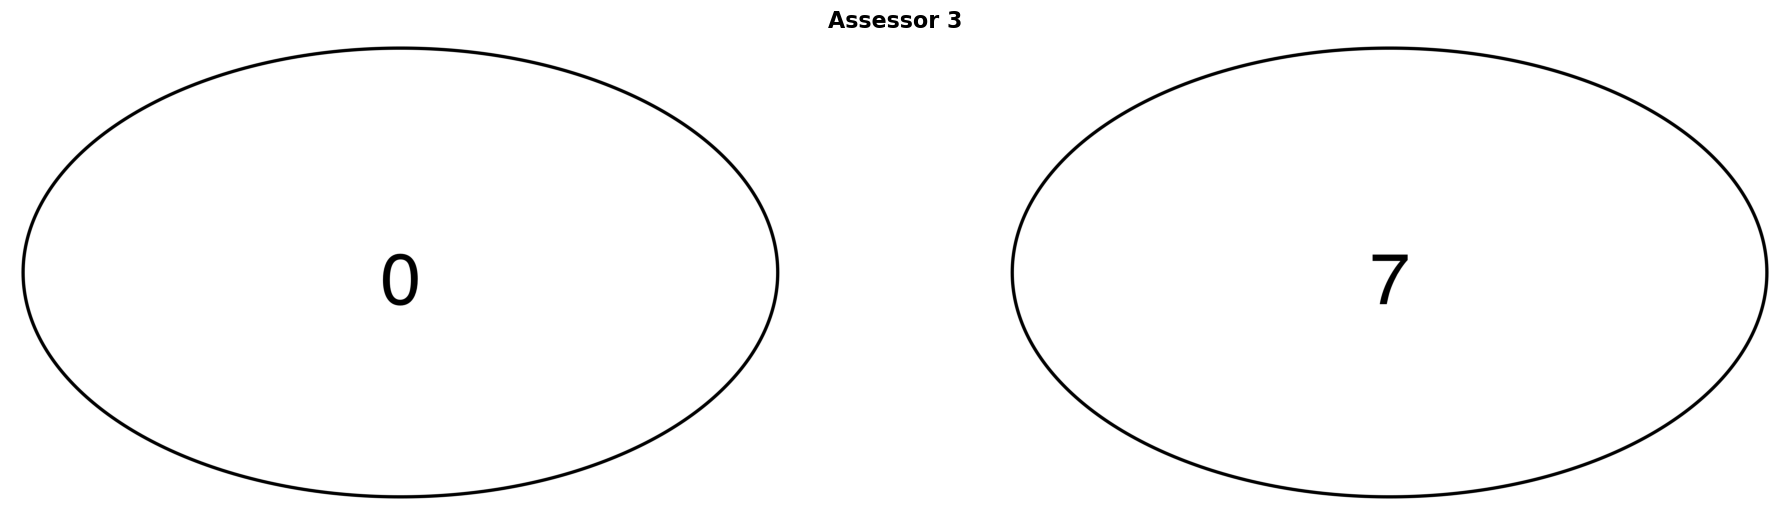

Assessor 4 has partial order matrix:
[3, 4, 6]
[[0 0 0]
 [0 0 0]
 [0 0 0]]


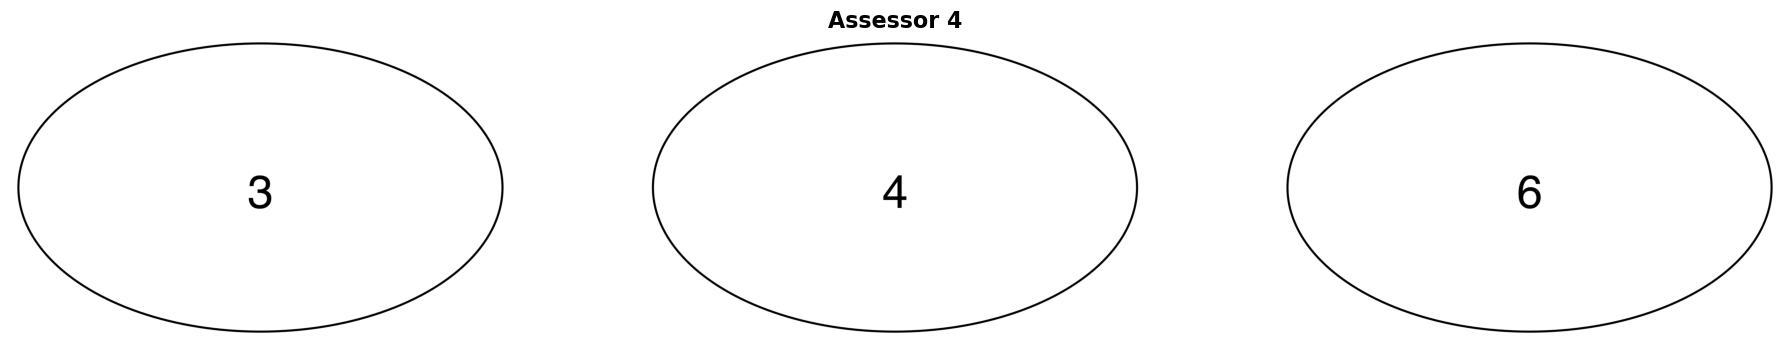

Assessor 5 has partial order matrix:
[3, 5]
[[0 0]
 [0 0]]


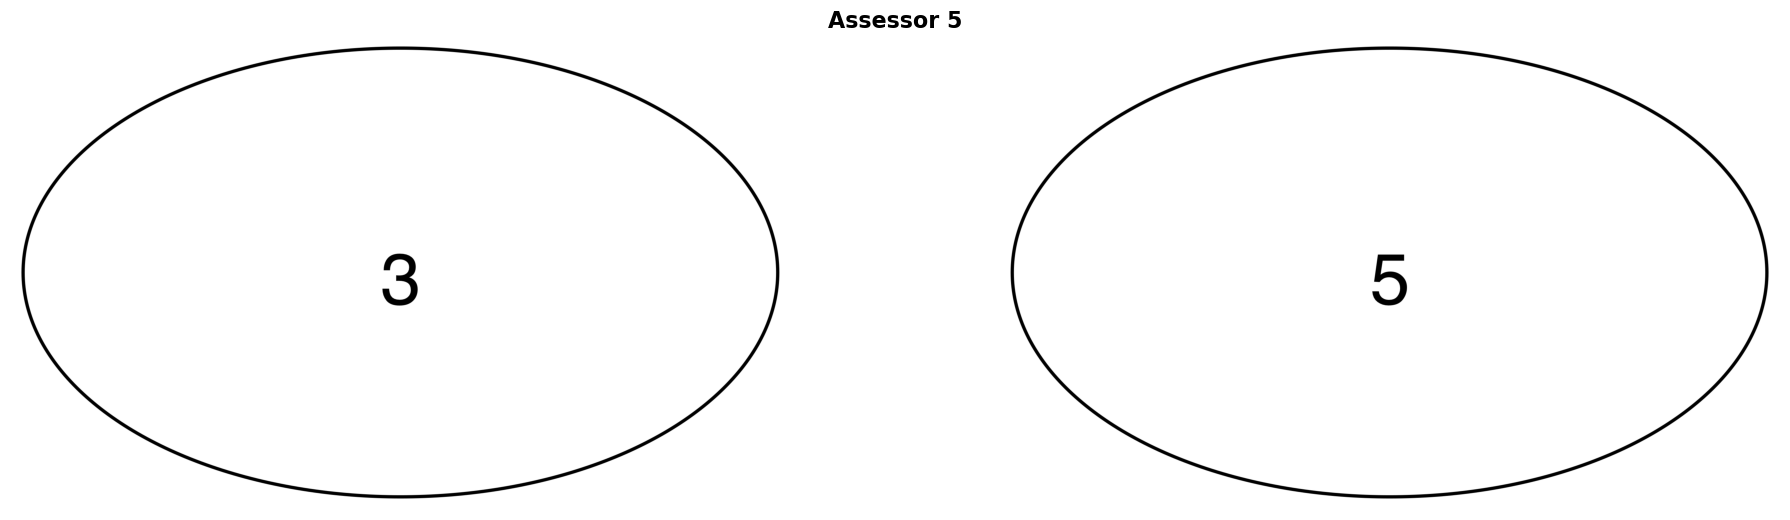

In [4]:
## Visualise the partial order matrix
for i in range(0,len(assessors)):
    if i==0:
        print(f"The global partial order matrix is:")
        print(BasicUtils.transitive_reduction(h_U_true[0]))
        PO_plot.visualize_partial_order(BasicUtils.transitive_reduction(h_U_true[0]), items ,f"Global H_0")

    print(f"Assessor {assessors[i]} has partial order matrix:")
    print(M_a_dict.get(assessors[i]))
    print(BasicUtils.transitive_reduction(h_U_true.get(assessors[i])))
    PO_plot.visualize_partial_order(BasicUtils.transitive_reduction(h_U_true.get(assessors[i])), M_a_dict.get(assessors[i]), f"Assessor {assessors[i]}")

## Sampling helpers

In [5]:
def _canonical_toposort(num_nodes: int, successors: List[List[int]], indegrees: List[int]) -> List[int]:
    import heapq

    heap = [i for i in range(num_nodes) if indegrees[i] == 0]
    heapq.heapify(heap)
    ordering = []

    while heap:
        node = heapq.heappop(heap)
        ordering.append(node)
        for nxt in successors[node]:
            indegrees[nxt] -= 1
            if indegrees[nxt] == 0:
                heapq.heappush(heap, nxt)

    if len(ordering) != num_nodes:
        raise ValueError("Adjacency matrix contains a cycle.")
    return ordering


def sample_frontier_softmax_trace(
    H: np.ndarray,
    beta: float,
    epsilon: float,
    rng: np.random.Generator,
    *,
    lambda_penalty: float = 1.0,
) -> List[int]:
    n = H.shape[0]
    if n == 0:
        return []

    H_bool = H.astype(bool)
    successors = [np.flatnonzero(H_bool[u]).tolist() for u in range(n)]
    indegrees = H_bool.sum(axis=0).astype(int).tolist()
    L_star = _canonical_toposort(n, successors, indegrees.copy())

    theta = beta * lambda_penalty
    remaining_order = list(L_star)
    remaining = set(remaining_order)
    unmet = indegrees[:]
    frontier = {i for i in remaining if unmet[i] == 0}

    order = []
    while remaining:
        if not frontier:
            chosen = min(remaining)
        else:
            if rng.random() < epsilon:
                chosen = rng.choice(list(remaining))
            else:
                rank = {a: i for i, a in enumerate(remaining_order)}
                frontier_list = list(frontier)
                scores = np.array([-theta * rank[a] for a in frontier_list], dtype=float)
                scores -= scores.max()
                weights = np.exp(scores)
                weights /= weights.sum()
                chosen = rng.choice(frontier_list, p=weights)

        order.append(chosen)
        remaining.remove(chosen)
        frontier.discard(chosen)
        remaining_order.remove(chosen)
        for v in successors[chosen]:
            if v in remaining:
                unmet[v] -= 1
                if unmet[v] == 0:
                    frontier.add(v)

    return order


def generate_choice_sets(
    items: List[int],
    num_tasks: int,
    rng: np.random.Generator,
    min_size: int,
    max_size: int,
) -> List[List[int]]:
    max_size_val = min(len(items), max_size)
    min_size_val = min(min_size, max_size_val)
    choice_sets = []
    for _ in range(num_tasks):
        if max_size_val <= min_size_val:
            choice_set = list(items)
        else:
            size = int(rng.integers(min_size_val, max_size_val + 1))
            choice_set = sorted(rng.choice(items, size=size, replace=False).tolist())
        choice_sets.append(choice_set)
    return choice_sets


def sample_orders_for_choice_sets(
    H: np.ndarray,
    choice_sets: List[List[int]],
    item_index: Dict[int, int],
    beta: float,
    epsilon: float,
    rng: np.random.Generator,
    lambda_penalty: float,
) -> List[List[int]]:
    orders = []
    for choice_set in choice_sets:
        local_ids = [item_index[g] for g in choice_set if g in item_index]
        if not local_ids:
            orders.append([])
            continue
        H_sub = H[np.ix_(local_ids, local_ids)]
        order_local = sample_frontier_softmax_trace(
            H_sub, beta=beta, epsilon=epsilon, rng=rng, lambda_penalty=lambda_penalty
        )
        order = [choice_set[i] for i in order_local]
        orders.append(order)
    return orders


def compute_cover_edge_probabilities(
    h_trace: List[Dict[int, np.ndarray]],
    assessor_id: int,
    burn_in_fraction: float,
) -> tuple[np.ndarray, int]:
    burn_in = int(len(h_trace) * burn_in_fraction)
    post = h_trace[burn_in:]
    if not post:
        raise ValueError("No H_trace samples after burn-in.")

    n = post[0][assessor_id].shape[0]
    counts = np.zeros((n, n), dtype=float)
    for sample in post:
        H = sample[assessor_id]
        H_red = BasicUtils.transitive_reduction_optimized(H.astype(np.int8))
        counts += H_red
    probs = counts / float(len(post))
    np.fill_diagonal(probs, 0.0)
    return probs, len(post)


## Generate choice sets and observed orders (20 lists per assessor)

In [6]:
choice_seed = config["random_seed"] + 31
rng_choices = np.random.default_rng(choice_seed)

choice_sets_full = {
    assessor: generate_choice_sets(
        M_a_dict[assessor],
        config["trace_count"],
        rng_choices,
        config["min_choice_set_size"],
        config["max_choice_set_size"],
    )
    for assessor in assessors
}


def simulate_orders(beta: float):
    trace_seed = config["random_seed"] + int(beta * 1000)
    rng_traces = np.random.default_rng(trace_seed)

    observed_orders = {}
    O_a_i_dict = {}
    for assessor in assessors:
        item_index = {g: i for i, g in enumerate(M_a_dict[assessor])}
        orders = sample_orders_for_choice_sets(
            h_U_true[assessor],
            choice_sets_full[assessor],
            item_index,
            beta=beta,
            epsilon=config["epsilon"],
            rng=rng_traces,
            lambda_penalty=config["mcmc"]["softmax_lambda"],
        )
        observed_orders[assessor] = orders
        O_a_i_dict[assessor] = choice_sets_full[assessor]

    return observed_orders, O_a_i_dict


## Run MCMC for each beta and compute metrics

In [7]:
results = []
mcmc_results_by_beta = {}

for beta in config["betas"]:
    print(f"Running beta={beta}...")
    HPO_LogLikelihoodCache_Optimized.SOFTMAX_FRONTIER_EPS = float(config["epsilon"])

    observed_orders, O_a_i_dict = simulate_orders(beta)
    item_to_index = {idx: idx for idx in items}

    mcmc_results = mcmc_simulation_hpo_k_optim(
        num_iterations=int(config["mcmc"]["num_iterations"]),
        M0=items,
        assessors=assessors,
        M_a_dict=M_a_dict,
        O_a_i_dict=O_a_i_dict,
        observed_orders=observed_orders,
        dr=float(config["mcmc"]["dr"]),
        drrt=float(config["mcmc"]["drrt"]),
        noise_option="softmax_queue_jump",
        rho_prior=1.0,
        noise_beta_prior=1.0,
        K_prior=int(config["K"]),
        fixed_K=int(config["K"]),
        random_seed=int(config["random_seed"]),
        cycle_length=int(config["mcmc"]["cycle_length"]),
        softmax_lambda=float(config["mcmc"]["softmax_lambda"]),
        softmax_beta_prior=tuple(config["mcmc"]["softmax_beta_prior"]),
        softmax_beta_stepsize=float(config["mcmc"]["softmax_beta_stepsize"]),
    )

    mcmc_results_by_beta[beta] = mcmc_results

    h_trace = mcmc_results.get("H_trace", [])
    if not h_trace:
        raise ValueError("H_trace missing from MCMC results.")

    expected_keys = [0] + assessors
    missing_keys = [a for a in expected_keys if a not in h_trace[0]]
    if missing_keys:
        raise ValueError(f"H_trace missing keys: {missing_keys}")

    for assessor in expected_keys:
        H_true = h_U_true.get(assessor)
        if H_true is None:
            continue
        H_true = BasicUtils.ensure_transitive_closure(H_true)
        H_true_cover = BasicUtils.transitive_reduction_optimized(H_true.astype(np.int8))

        edge_probs, n_post = compute_cover_edge_probabilities(
            h_trace=h_trace,
            assessor_id=assessor,
            burn_in_fraction=float(config["mcmc"]["burn_in_fraction"]),
        )

        pred_adj = (edge_probs >= config["analysis"]["edge_prob_threshold"]).astype(np.int8)
        np.fill_diagonal(pred_adj, 0)

        shd = structural_hamming_distance(H_true_cover, pred_adj)
        precision, recall = precision_recall(H_true_cover, pred_adj)
        f1 = f1_score(precision, recall)
        accuracy = edge_accuracy(H_true_cover, pred_adj)
        mean_entropy, not_identifiable = identifiability_metrics(
            edge_probs,
            float(config["analysis"]["identifiability_entropy_threshold"]),
        )

        results.append(
            {
                "beta": beta,
                "epsilon": config["epsilon"],
                "K": config["K"],
                "assessor_id": assessor,
                "trace_count": config["trace_count"],
                "shd": shd,
                "precision": precision,
                "recall": recall,
                "f1": f1,
                "accuracy": accuracy,
                "mean_entropy": mean_entropy,
                "not_identifiable": not_identifiable,
                "posterior_samples": n_post,
            }
        )

    waic, lppd, p_waic = compute_waic_from_results(
        mcmc_results,
        observed_orders,
        O_a_i_dict,
        M_a_dict,
        item_to_index,
        burn_in_fraction=float(config["mcmc"]["burn_in_fraction"]),
        noise_option="softmax_queue_jump",
    )
    print(f"beta={beta}: WAIC={waic:.3f} lppd={lppd:.3f} p_waic={p_waic:.3f}")


output_path = config["output_dir"] / "synthetic_recovery_results.json"
with output_path.open("w", encoding="utf-8") as f:
    json.dump({"config": config, "results": results}, f, indent=2)
print("Saved results to:", output_path)


Running beta=0.8...
📊 Update Schedule Frequencies: {'U0': 108, 'Ua': 271, 'rho': 27, 'tau': 40, 'rho_tau': 27, 'noise': 27}
📋 Sequential update cycle length: 500
Iteration 2500/50000 - Accept Rate: 53.16%
Iteration 5000/50000 - Accept Rate: 54.86%
Iteration 7500/50000 - Accept Rate: 56.19%
Iteration 10000/50000 - Accept Rate: 56.73%
Iteration 12500/50000 - Accept Rate: 57.00%
Iteration 15000/50000 - Accept Rate: 57.21%
Iteration 17500/50000 - Accept Rate: 57.57%
Iteration 20000/50000 - Accept Rate: 57.75%
Iteration 22500/50000 - Accept Rate: 57.78%
Iteration 25000/50000 - Accept Rate: 57.97%
Iteration 27500/50000 - Accept Rate: 58.16%
Iteration 30000/50000 - Accept Rate: 58.26%
Iteration 32500/50000 - Accept Rate: 58.22%
Iteration 35000/50000 - Accept Rate: 58.27%
Iteration 37500/50000 - Accept Rate: 58.20%
Iteration 40000/50000 - Accept Rate: 57.93%
Iteration 42500/50000 - Accept Rate: 57.80%
Iteration 45000/50000 - Accept Rate: 57.84%
Iteration 47500/50000 - Accept Rate: 57.76%
Itera

TypeError: Object of type PosixPath is not JSON serializable

## Metrics summary

In [ ]:
if HAVE_PANDAS:
    df = pd.DataFrame(results)
    display(df.sort_values(["beta", "assessor_id"]))
else:
    for row in results:
        print(row)


,beta,epsilon,K,assessor_id,trace_count,shd,precision,recall,f1,accuracy,mean_entropy,not_identifiable,posterior_samples
0,0.8,0.01,2,0,20,8,0.666667,0.222222,0.333333,0.857143,2.840160e-01,False,250
1,0.8,0.01,2,1,20,1,1.000000,0.857143,0.923077,0.976190,1.424883e-01,False,250
2,0.8,0.01,2,2,20,0,1.000000,1.000000,1.000000,1.000000,6.669072e-02,False,250
3,0.8,0.01,2,3,20,0,0.000000,0.000000,0.000000,1.000000,2.172327e-08,False,250
4,0.8,0.01,2,4,20,0,0.000000,0.000000,0.000000,1.000000,2.172327e-08,False,250
5,0.8,0.01,2,5,20,0,0.000000,0.000000,0.000000,1.000000,2.172327e-08,False,250
6,1.5,0.01,2,0,20,10,0.400000,0.222222,0.285714,0.821429,2.342981e-01,False,250
7,1.5,0.01,2,1,20,6,0.571429,0.571429,0.571429,0.857143,8.544109e-02,False,250
8,1.5,0.01,2,2,20,1,1.000000,0.833333,0.909091,0.976190,7.042100e-02,False,250
9,1.5,0.01,2,3,20,0,0.000000,0.000000,0.000000,1.000000,2.172327e-08,False,250


## PO_plot visualizations (global + per-assessor)
Requires `networkx` for plotting. Plots are saved into `output_dir/po_plots`.


In [ ]:
def _save_current_plot(path: Path, *, dpi: int = 200) -> None:
    path.parent.mkdir(parents=True, exist_ok=True)
    plt.savefig(path, dpi=dpi, bbox_inches="tight")
    plt.close()
    print(f"Saved plot to: {path}")


class _PlotShowSaver:
    def __init__(self, prefix: Path, *, dpi: int) -> None:
        self.prefix = prefix
        self.dpi = dpi
        self._orig_show = None
        self._count = 0

    def __enter__(self):
        self._orig_show = plt.show

        def _show(*args, **kwargs):
            self._count += 1
            out_path = self.prefix.with_name(f"{self.prefix.name}_{self._count}.png")
            _save_current_plot(out_path, dpi=self.dpi)

        plt.show = _show
        return self

    def __exit__(self, exc_type, exc, tb) -> None:
        if self._orig_show is not None:
            plt.show = self._orig_show


if not PO_PLOT_AVAILABLE:
    print(f"PO_plot unavailable: {PO_PLOT_IMPORT_ERROR}")
    print("Install networkx to enable PO_plot visualizations.")
else:
    po_dir = config["output_dir"] / "po_plots"
    po_dir.mkdir(parents=True, exist_ok=True)

    index_to_item = {i: item for i, item in enumerate(items)}
    global_items = [str(index_to_item[i]) for i in sorted(index_to_item)]

    for beta, mcmc_results in mcmc_results_by_beta.items():
        h_trace = mcmc_results.get("H_trace", [])
        if not h_trace:
            continue

        expected_keys = [0] + assessors
        for assessor in expected_keys:
            if assessor not in h_U_true or assessor not in h_trace[0]:
                continue

        h_inferred = {}
        for assessor in expected_keys:
            edge_probs, _ = compute_cover_edge_probabilities(
                h_trace=h_trace,
                assessor_id=assessor,
                burn_in_fraction=float(config["mcmc"]["burn_in_fraction"]),
            )
            inferred_reduced = (
                edge_probs >= config["analysis"]["edge_prob_threshold"]
            ).astype(np.int8)
            np.fill_diagonal(inferred_reduced, 0)
            inferred_closure = BasicUtils.transitive_closure(inferred_reduced.astype(np.int8))
            h_inferred[assessor] = inferred_closure

        if 0 in h_U_true and 0 in h_inferred:
            prefix = po_dir / f"po_global_beta{beta}"
            with _PlotShowSaver(prefix, dpi=200):
                PO_plot.compare_and_visualize_global(
                    h_U_true[0],
                    h_inferred[0],
                    index_to_item,
                    global_items,
                    do_transitive_reduction=True,
                )

        for assessor in assessors:
            if assessor not in h_U_true or assessor not in h_inferred:
                continue
            prefix = po_dir / f"po_assessor{assessor}_beta{beta}"
            index_to_item_local = {i: item for i, item in enumerate(M_a_dict[assessor])}
            Ma_labels = [str(item) for item in M_a_dict[assessor]]
            with _PlotShowSaver(prefix, dpi=200):
                PO_plot.compare_and_visualize_assessor(
                    assessor,
                    Ma_labels,
                    h_U_true[assessor],
                    h_inferred[assessor],
                    index_to_item_local,
                    do_transitive_reduction=True,
                )


Saved plot to: notebooks/outputs/hpo_synthetic_recovery_notebook/po_plots/po_global_beta0.8_1.png
Saved plot to: notebooks/outputs/hpo_synthetic_recovery_notebook/po_plots/po_global_beta0.8_2.png

Missing (true PO edges not in inferred PO):
0 < 3
1 < 3
2 < 0
4 < 0
5 < 2
7 < 5
7 < 6

Redundant (inferred PO edges not in true PO):
5 < 0
Saved plot to: notebooks/outputs/hpo_synthetic_recovery_notebook/po_plots/po_assessor1_beta0.8_1.png
Saved plot to: notebooks/outputs/hpo_synthetic_recovery_notebook/po_plots/po_assessor1_beta0.8_2.png

Missing edges for assessor 1:
2 < 5

No redundant edges for assessor 1.
Saved plot to: notebooks/outputs/hpo_synthetic_recovery_notebook/po_plots/po_assessor2_beta0.8_1.png
Saved plot to: notebooks/outputs/hpo_synthetic_recovery_notebook/po_plots/po_assessor2_beta0.8_2.png

No missing edges for assessor 2.

No redundant edges for assessor 2.
Saved plot to: notebooks/outputs/hpo_synthetic_recovery_notebook/po_plots/po_assessor3_beta0.8_1.png
Saved plot to: n